# Joystick coordinate check (simple version)

What this notebook does:
1. Point at a BCI2000 `.dat` file
2. Check whether joystick X and Y are stored
3. Print some summary numbers
4. Plot X, Y, and the 2D path
5. Peek at the neural signal channels
6. Check signal quality / plot basic signal metrics

In [1]:
# Libraries we need
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from BCI2000Tools.FileReader import bcistream

## 1. Set the `.dat` file path

Change the path string below to your file, then run the cell.

In [ ]:
# Change this path if you want to look at a different recording
dat_path = r"C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R10.dat"
# This file path needs an 'r' since it contains backslashes


print("Using file:")
print(dat_path)

Using file:
C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R05.dat


## 2. Load the file and look for joystick states

In BCI2000, joystick values are stored as **states** (like `JoystickX`), not as EEG channels.

This cell opens the file and prints basic info.

In [3]:
# Open the BCI2000 .dat file
stream = bcistream(dat_path)

# List of all state names in this file
state_names = list(stream.statedefs.keys())
state_names.sort()

# Recording settings stored in the file header
params = stream.params

# Look for the usual joystick state names
if "JoystickX" in stream.statedefs:
    x_state = "JoystickX"
else:
    x_state = None

if "JoystickY" in stream.statedefs:
    y_state = "JoystickY"
else:
    y_state = None

has_both_axes = (x_state is not None) and (y_state is not None)

# Which application modules were used during recording?
app_chain = params.get("ApplicationFilterChain", [])
app_modules = []
for row in app_chain:
    # Each row looks like: ['arduino_joystick_Task', '3']
    app_modules.append(row[0])

print("File:", dat_path)
print("Channels:", stream.nchan)
print("Samples:", stream.samples())
print("Sampling rate (Hz):", stream.samplingfreq_hz)
print("Application modules:", app_modules)
print("SerialPort:", params.get("SerialPort", "(none)"))
print()

if has_both_axes:
    print("RESULT: YES - this file stores joystick X and Y.")
elif (x_state is not None) or (y_state is not None):
    print("RESULT: PARTIAL - only one axis was found.")
else:
    print("RESULT: NO - JoystickX / JoystickY were not found.")

print("X state:", x_state)
print("Y state:", y_state)

# Print joystick related names
print()
print("Joystick/cursor-related states:")
for name in state_names:
    name_lower = name.lower()
    if ("button" in name_lower):
        print(" -", name)

print()
print("All states:")
for name in state_names:
    print(" -", name)

File: C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R05.dat
Channels: 16
Samples: 2876000
Sampling rate (Hz): 30000.0
Application modules: ['arduino_joystick_Task', 'KeystrokeFilter', 'ParallelPortFilter']
SerialPort: COM3

RESULT: YES - this file stores joystick X and Y.
X state: JoystickX
Y state: JoystickY

Joystick/cursor-related states:
 - JoystickButton

All states:
 - AudioBufferTime
 - AudioPresentationTime
 - CursorX
 - CursorY
 - FilePart
 - JoystickButton
 - JoystickX
 - JoystickY
 - MovementStarted
 - MovementTimeMs
 - Notes
 - PreStimulusTime
 - PresentationDisplayed
 - PresentationFrame
 - PresentationRequested
 - PresentationTime
 - ReactionTimeMs
 - Recording
 - Running
 - SourceChannel1
 - SourceTime
 - StimulusTime
 - TargetHit
 - TargetIndex
 - TaskBlock
 - TaskCondition
 - TaskPhase
 - TaskTrial
 - TotalTimeMs
 - VideoStimulusFrame
 - __pad0
 - __pad1
 - __pad2
 - __pad3


## 3. Decode and summarize axis / task states

`stream.decode(...)` reads the data out of the file.

- `sig` = neural / signal channels
- `states` = a dictionary of state time series (joystick, task markers, etc.)

In [4]:
# Which states do we want to look at?
wanted = []

if x_state is not None:
    wanted.append(x_state)
if y_state is not None:
    wanted.append(y_state)

# Add a few useful task-related states if they exist
extra_names = [
    "JoystickButton",
    "TaskPhase",
    "TargetIndex",
    "CursorX",
    "CursorY",
    "TaskTrial",
    "TargetHit",
]

for name in extra_names:
    if name in stream.statedefs:
        if name not in wanted:
            wanted.append(name)

# Decode the whole file
# nsamp="all" means: read every sample
sig, states = stream.decode(nsamp="all", states=wanted)
sig = np.asarray(sig)

# Build a simple summary table, one row per state
rows = []

for name in wanted:
    # states[name] is the time series for that state
    # .ravel() flattens it to 1D (a plain list of numbers)
    values = np.asarray(states[name]).ravel()

    # How many times did the value change from one sample to the next?
    differences = np.diff(values)
    n_changes = np.count_nonzero(differences)

    row = {
        "state": name,
        "min": values.min(),
        "max": values.max(),
        "mean": values.mean(),
        "n_unique": len(np.unique(values)),
        "n_changes": int(n_changes),
        "n_samples": len(values),
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df = summary_df.set_index("state")
summary_df

,min,max,mean,n_unique,n_changes,n_samples
state,,,,,,
JoystickX,39,930,489.949207,262,1412,2876000
JoystickY,32,1023,528.774353,377,1048,2876000
JoystickButton,1,1,1.000000,1,0,2876000
TaskPhase,0,5,2.760834,6,60,2876000
TargetIndex,0,5,3.137836,5,7,2876000
CursorX,93,984,527.108050,276,1413,2876000
CursorY,0,1023,526.551255,392,1049,2876000
TaskTrial,0,10,6.074170,11,10,2876000
TargetHit,0,1,0.000100,2,18,2876000


## 4. Plot joystick X/Y over time

This only runs if both `JoystickX` and `JoystickY` were found.

Available trial numbers: [ 0  1  2  3  4  5  6  7  8  9 10]
Plotting trial 3
Samples in this trial: 186432


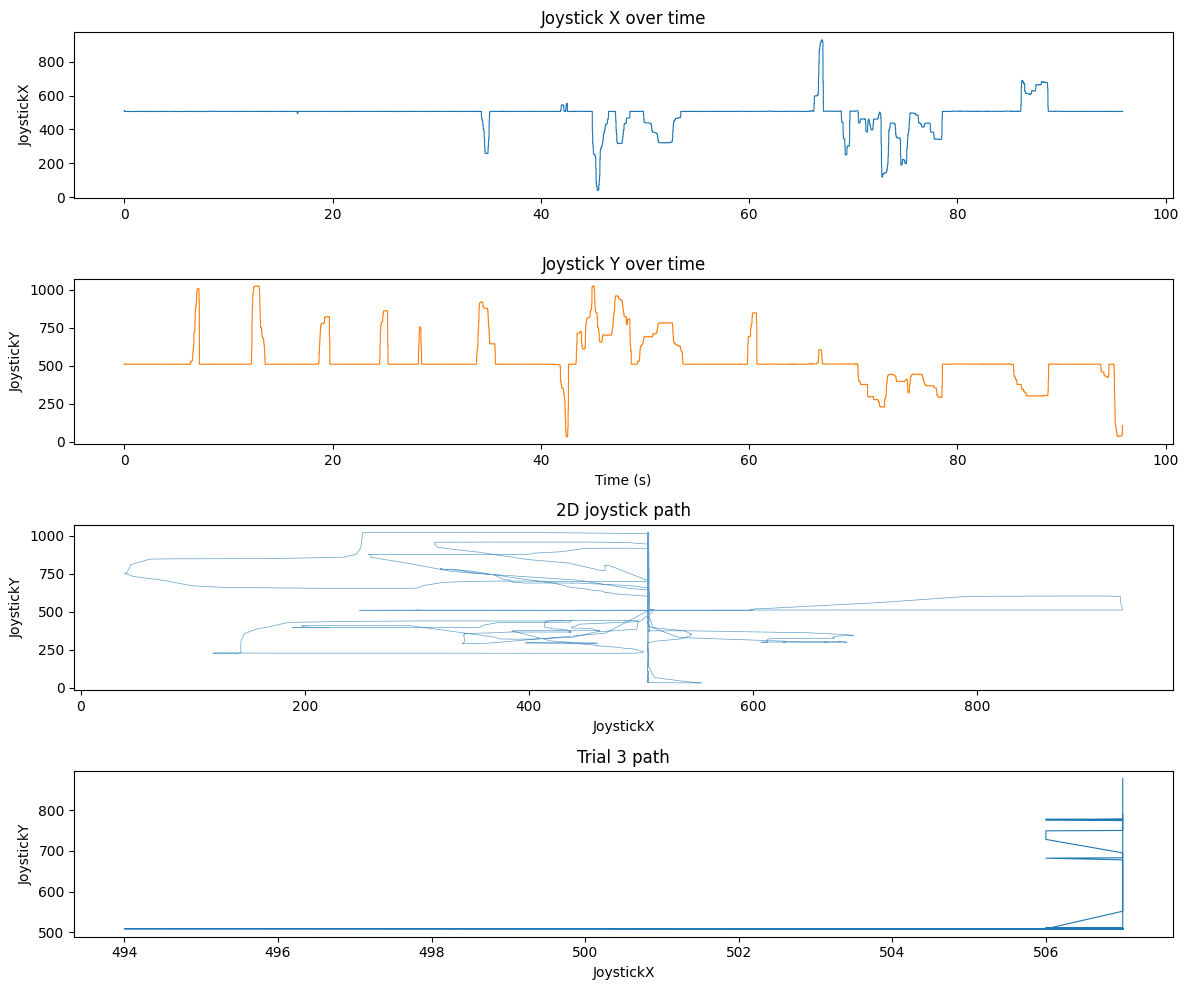

In [11]:
if not has_both_axes:
    print("Skipping plot: need both JoystickX and JoystickY.")
else:
    n_samples = stream.samples()
    sample_rate = stream.samplingfreq_hz
    t = np.arange(n_samples) / sample_rate

    jx = np.asarray(states[x_state]).ravel()
    jy = np.asarray(states[y_state]).ravel()

    trial = np.asarray(states["TaskTrial"]).ravel()
    available_trials = np.unique(trial)
    print("Available trial numbers:", available_trials)

    # ---- CHANGE THIS to pick which trial to show in plot 4 ----
    selected_trial = 3
    # ----------------------------------------------------------

    fig, axes = plt.subplots(4, 1, figsize=(12, 10))

    axes[0].plot(t, jx, linewidth=0.8)
    axes[0].set_ylabel(x_state)
    axes[0].set_title("Joystick X over time")

    axes[1].plot(t, jy, linewidth=0.8, color="C1")
    axes[1].set_ylabel(y_state)
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Joystick Y over time")

    axes[2].plot(jx, jy, linewidth=0.5, alpha=0.7)
    axes[2].set_xlabel(x_state)
    axes[2].set_ylabel(y_state)
    axes[2].set_title("2D joystick path")

    if selected_trial in available_trials:
        mask = trial == selected_trial
        axes[3].plot(jx[mask], jy[mask], linewidth=0.8)
        axes[3].set_xlabel(x_state)
        axes[3].set_ylabel(y_state)
        axes[3].set_title("Trial " + str(selected_trial) + " path")
        print("Plotting trial", selected_trial)
        print("Samples in this trial:", int(mask.sum()))
    else:
        axes[3].set_title("Trial " + str(selected_trial) + " not found")
        print("Trial", selected_trial, "not found.")
        print("Choose one of:", available_trials)

    fig.tight_layout()
    plt.show()

## 5. Optional: peek at signal channels

This shows the continuous signal channels (EEG / neural / signal-generator data).

Joystick X/Y should **not** show up here — they live in states.

In [ ]:
# Channel names from the file header (may be empty)
channel_names = params.get("ChannelNames", [])
channel_names = list(channel_names)

# If names are missing, make simple names like ch0, ch1, ...
n_channels = sig.shape[0]
if len(channel_names) < n_channels:
    channel_names = []
    for i in range(n_channels):
        channel_names.append("ch" + str(i))

# Summarize each channel
chan_rows = []

for i in range(n_channels):
    ch = np.asarray(sig[i]).ravel()

    row = {
        "channel": channel_names[i],
        "min": float(ch.min()),
        "max": float(ch.max()),
        "mean": float(ch.mean()),
        "std": float(ch.std()),
    }
    chan_rows.append(row)

channel_df = pd.DataFrame(chan_rows)
channel_df = channel_df.set_index("channel")
channel_df

,min,max,mean,std
channel,,,,
ch0,-171.500000,171.500000,0.031286,91.463463
ch1,-171.500000,171.500000,0.025448,91.459854
ch2,-171.500000,171.500000,0.028383,91.452789
ch3,-171.600006,171.600006,0.035716,91.462631
ch4,-171.500000,171.500000,0.037273,91.460991
ch5,-171.600006,171.400009,0.037853,91.461807
ch6,-171.600006,171.500000,0.025483,91.463943
ch7,-171.500000,171.500000,0.026333,91.461754
ch8,-171.500000,171.600006,0.042097,91.461006


## 6. Signal quality check

This section looks at the **continuous signal channels** (`sig`), not the joystick states.

We will:
1. Summarize basic quality metrics per channel
2. Compare channel strength (RMS)
3. Plot a short time window of a few channels
4. Look at a simple frequency spectrum for one channel

Run the earlier decode cell first so `sig` exists.

### 6a. Basic metrics per channel

For each channel we compute:
- **mean** — average value (large offset can mean drift / DC bias)
- **std / RMS-like spread** — how much the signal wiggles
- **peak-to-peak** — max - min
- **n_flat** — how many samples are exactly equal to the previous sample (lots of flats can mean a dead/stuck channel)

In [ ]:
# Make sure we have channel names (same idea as section 5)
channel_names = params.get("ChannelNames", [])
channel_names = list(channel_names)

n_channels = sig.shape[0]
if len(channel_names) < n_channels:
    channel_names = []
    for i in range(n_channels):
        channel_names.append("ch" + str(i))

sample_rate = stream.samplingfreq_hz
n_samples = sig.shape[1]
duration_sec = n_samples / sample_rate

print("Signal shape (channels, samples):", sig.shape)
print("Sampling rate (Hz):", sample_rate)
print("Duration (seconds):", round(duration_sec, 2))
print()

quality_rows = []

for i in range(n_channels):
    ch = np.asarray(sig[i]).ravel()

    # How often does the value stay exactly the same as the previous sample?
    n_flat = int(np.count_nonzero(np.diff(ch) == 0))
    flat_fraction = n_flat / max(len(ch) - 1, 1)

    row = {
        "channel": channel_names[i],
        "mean": float(ch.mean()),
        "std": float(ch.std()),
        "rms": float(np.sqrt(np.mean(ch ** 2))),
        "min": float(ch.min()),
        "max": float(ch.max()),
        "peak_to_peak": float(ch.max() - ch.min()),
        "flat_fraction": float(flat_fraction),
    }
    quality_rows.append(row)

quality_df = pd.DataFrame(quality_rows)
quality_df = quality_df.set_index("channel")
quality_df

Signal shape (channels, samples): (16, 2876000)
Sampling rate (Hz): 30000.0
Duration (seconds): 95.87



,mean,std,rms,min,max,peak_to_peak,flat_fraction
channel,,,,,,,
ch0,0.031286,91.463463,91.463463,-171.500000,171.500000,343.000000,0.003302
ch1,0.025448,91.459854,91.459869,-171.500000,171.500000,343.000000,0.003329
ch2,0.028383,91.452789,91.452820,-171.500000,171.500000,343.000000,0.003308
ch3,0.035716,91.462631,91.462669,-171.600006,171.600006,343.200012,0.003329
ch4,0.037273,91.460991,91.461006,-171.500000,171.500000,343.000000,0.003354
ch5,0.037853,91.461807,91.461769,-171.600006,171.400009,343.000000,0.003260
ch6,0.025483,91.463943,91.463943,-171.600006,171.500000,343.100006,0.003395
ch7,0.026333,91.461754,91.461746,-171.500000,171.500000,343.000000,0.003252
ch8,0.042097,91.461006,91.461006,-171.500000,171.600006,343.100006,0.003315


### 6b. Compare channel strength (RMS)

RMS is a simple “how big is this channel?” score.  
Channels that are much quieter or much louder than the others are worth a closer look.

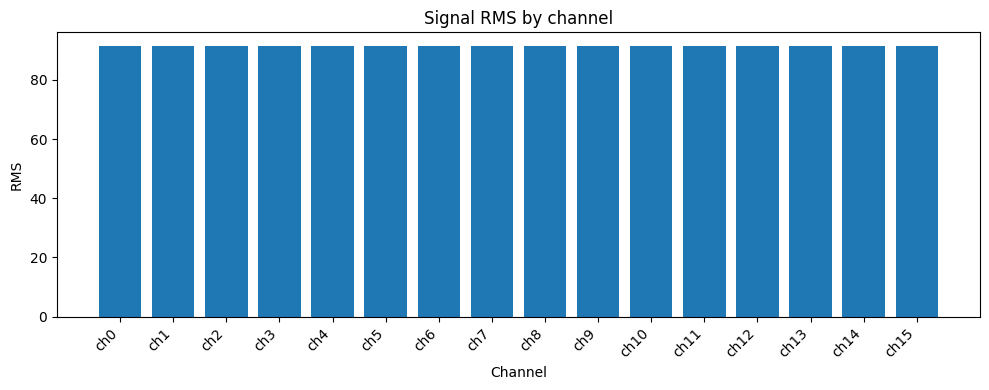

Median RMS across channels: 91.46100616455078


Also check flat_fraction in the table above.
Values close to 1.0 can mean a stuck / disconnected channel.


In [ ]:
rms_values = quality_df["rms"].values
channel_labels = list(quality_df.index)

plt.figure(figsize=(10, 4))
plt.bar(range(n_channels), rms_values)
plt.xticks(range(n_channels), channel_labels, rotation=45, ha="right")
plt.ylabel("RMS")
plt.xlabel("Channel")
plt.title("Signal RMS by channel")
plt.tight_layout()
plt.show()

# Simple flags: channels far from the median RMS
median_rms = float(np.median(rms_values))
print("Median RMS across channels:", median_rms)
print()

for i in range(n_channels):
    rms = float(rms_values[i])
    name = channel_labels[i]

    if median_rms > 0:
        ratio = rms / median_rms
    else:
        ratio = 0.0

    if ratio < 0.2:
        print("QUIET?:", name, "RMS =", rms, "(ratio to median =", round(ratio, 3), ")")
    elif ratio > 5.0:
        print("LOUD?:", name, "RMS =", rms, "(ratio to median =", round(ratio, 3), ")")

print()
print("Also check flat_fraction in the table above.")
print("Values close to 1.0 can mean a stuck / disconnected channel.")

### 6c. Plot a short time window

Plotting every sample of a long high-rate file is slow and hard to read.  
Here we only plot the **first few seconds** of a few channels.

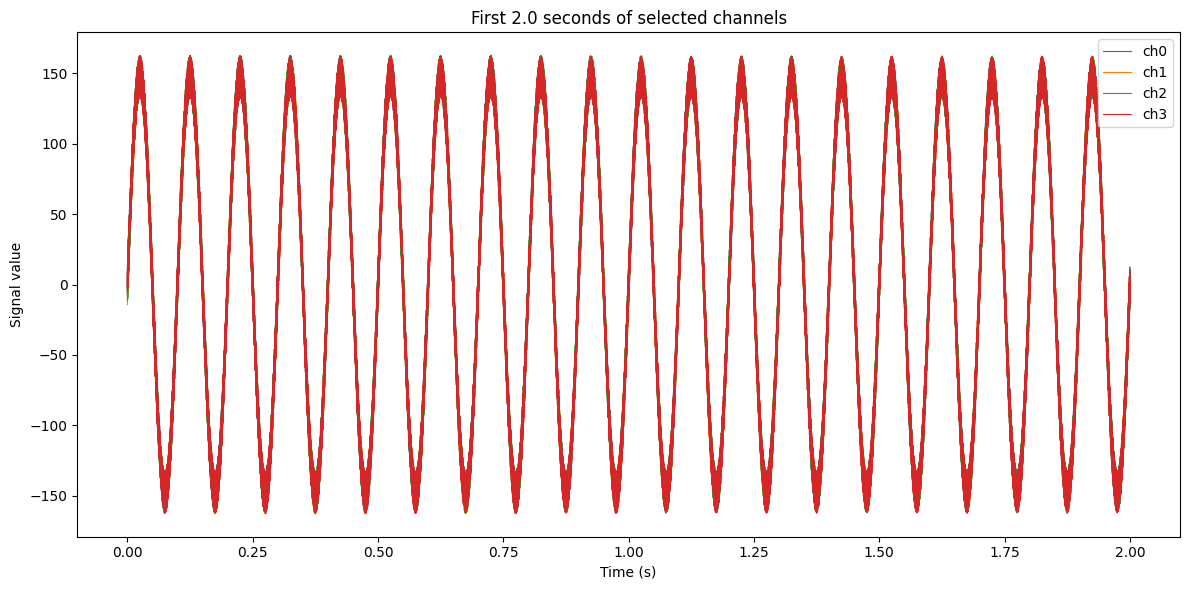

In [ ]:
# How many seconds to show, and which channels (0-based indexes)
window_seconds = 2.0
channels_to_plot = [0, 1, 2, 3]

n_window = int(window_seconds * sample_rate)
if n_window > n_samples:
    n_window = n_samples

t_window = np.arange(n_window) / sample_rate

plt.figure(figsize=(12, 6))

for ch_index in channels_to_plot:
    if ch_index >= n_channels:
        continue

    # Take only the first n_window samples from this channel
    y = np.asarray(sig[ch_index, :n_window]).ravel()
    plt.plot(t_window, y, linewidth=0.8, label=channel_names[ch_index])

plt.xlabel("Time (s)")
plt.ylabel("Signal value")
plt.title("First " + str(window_seconds) + " seconds of selected channels")
plt.legend()
plt.tight_layout()
plt.show()

### 6d. Simple frequency spectrum (one channel)

This uses a basic FFT on a short snippet.  
Big spikes at specific frequencies (for example near 60 Hz) can hint at line noise.

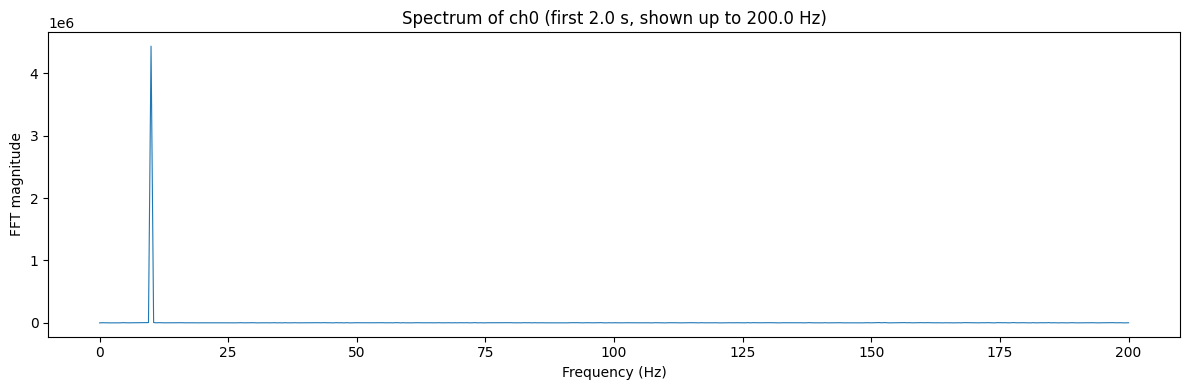

Strongest peak in shown range:
  frequency (Hz): 10.0
  magnitude: 4431851.0


In [ ]:
# Which channel to inspect, and how long a snippet to use
spectrum_channel = 0
spectrum_seconds = 2.0

n_spec = int(spectrum_seconds * sample_rate)
if n_spec > n_samples:
    n_spec = n_samples

# Take a short snippet and remove the mean (DC offset)
snippet = np.asarray(sig[spectrum_channel, :n_spec]).ravel()
snippet = snippet - snippet.mean()

# FFT magnitudes
fft_vals = np.fft.rfft(snippet)
freqs = np.fft.rfftfreq(len(snippet), d=1.0 / sample_rate)
power = np.abs(fft_vals)

# For high sampling rates, only show a useful frequency range
max_freq_to_show = 200.0
keep = freqs <= max_freq_to_show

plt.figure(figsize=(12, 4))
plt.plot(freqs[keep], power[keep], linewidth=0.8)
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT magnitude")
plt.title(
    "Spectrum of "
    + channel_names[spectrum_channel]
    + " (first "
    + str(spectrum_seconds)
    + " s, shown up to "
    + str(max_freq_to_show)
    + " Hz)"
)
plt.tight_layout()
plt.show()

# Print the frequency with the largest peak in that range
if np.any(keep):
    idx_max = int(np.argmax(power[keep]))
    print("Strongest peak in shown range:")
    print("  frequency (Hz):", freqs[keep][idx_max])
    print("  magnitude:", power[keep][idx_max])